MDP

In [1]:
# MDP의 한 사이클
def mdp_cycle():
    """
    t=0: 초기 상태
    """
    state = env.reset()  # S_0

    while not done:
        # 1. 현재 상태 관찰
        print(f"현재 상태: {state}")

        # 2. 정책에 따라 행동 선택
        action = policy(state)
        # π(a|s) 주어진 상황에서 어떤 행동을 취할 확률 : 정책(π)
        print(f"선택한 행동: {action}")

        # 3. 환경과 상호작용
        next_state, reward, done, info = env.step(action)
        print(f"보상: {reward}")
        print(f"다음 상태: {next_state}")

        # 4. 상태 업데이트
        # 행동을 취해서 다음 단계, 즉 다음 상태(next_state)로 전이했으니깐
        # 다음 상태가 현재 상태로 업데이트 됨
        state = next_state

    print("에피소드 종료!")

In [17]:
'''
**구체적인 예시 - CartPole:**

t=0: State=[0.01, 0, 0.02, 0] → Action=1(오른쪽) → Reward=+1 → Next_State=[0.02, 0.1, 0.019, -0.05]
t=1: State=[0.02, 0.1, 0.019, -0.05] → Action=0(왼쪽) → Reward=+1 → Next_State=[0.022, -0.08, 0.018, 0.03]
t=2: State=[0.022, -0.08, 0.018, 0.03] → Action=1(오른쪽) → Reward=+1 → Next_State=[0.021, 0.11, 0.019, -0.07]
t=500: 막대가 500 스텝 동안 서있음 → 성공! 총 보상 = 500

'''


'\n**구체적인 예시 - CartPole:**\n\nt=0: State=[0.01, 0, 0.02, 0] → Action=1(오른쪽) → Reward=+1 → Next_State=[0.02, 0.1, 0.019, -0.05]\nt=1: State=[0.02, 0.1, 0.019, -0.05] → Action=0(왼쪽) → Reward=+1 → Next_State=[0.022, -0.08, 0.018, 0.03]\nt=2: State=[0.022, -0.08, 0.018, 0.03] → Action=1(오른쪽) → Reward=+1 → Next_State=[0.021, 0.11, 0.019, -0.07]\nt=500: 막대가 500 스텝 동안 서있음 → 성공! 총 보상 = 500\n\n'

Value Function_Bell Equation

In [2]:
# V(s)

# V(s) = "이 상태에서 시작해서 끝까지 얻을 보상의 평균"

def V(state, policy, gamma=0.9):
    """
    state(주어진 상태)에서 시작해서 policy(정책)를 따라갈 때
    미래의 모든 보상을 할인(gamma=0.9 할인율)하여 합산한 기댓값
    """
    total_reward = 0
    current_state = state
    discount = 1.0

    while not done:
        action = policy(current_state)
        next_state, reward = env.step(action)
        total_reward += discount * reward
        discount *= gamma
        current_state = next_state

    return total_reward

V(s) 와 Q(s, a) 관계
- 상태의 가치 V(s)는 각 행동의 가치를 정책 확률로 가중 평균한 것

In [3]:
import numpy as np

# 1. 상태 및 Q-값 정의
state = [0.02, 0.5, 0.03, -0.8]
q_values = {
    0: 45.2,  # Action 0: 왼쪽
    1: 78.5   # Action 1: 오른쪽
}

# 2. 최적 행동 선택 (Greedy Action)
# q_values의 값들 중 최대값의 인덱스를 반환
best_action = max(q_values, key=q_values.get)
print(f"최적 행동: {best_action} (가치: {q_values[best_action]})")

# 3. V(state) 계산
# 정책(pi)이 각 행동을 50% 확률로 선택한다고 가정할 때의 기대값
policy = {0: 0.5, 1: 0.5}
v_state = sum(policy[a] * q_values[a] for a in q_values)

print(f"상태 가치 V(state): {v_state:.2f}")

최적 행동: 1 (가치: 78.5)
상태 가치 V(state): 61.85


In [20]:
# 벨만 방정식의 아이디어
# >> 현재 가치 = 즉각적인 보상 + 미래 가치
# 만약 학자금 대출(100만원) 이 있다면,
# >> 총 대출 받은 금액(빚) 100만원 = 이번 달 내야할 할부금 (1만원) + 남은 잔금(빚) (이자 포함되어 있음,2%)
# 현재 상태 가치(V(s)) = 지금 받을 보상 + (할인된 gamma) 다음 상태 가치

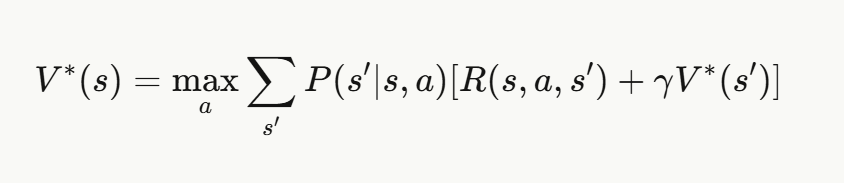

최적 가치 함수 (벨만방정식)
- 최적가치는 V*(s) 는 가장 좋은 행동(a) 선택했을 때 가치인데, 정책에 대한 기대값(합)이 아니라 최대값(max) 사용함
- 최적가치 = 즉각적인 보상 R(s,a,s')와 미래가치 (gamma V*(s')) 가중평균한 누적합의 최대화하는 값(max)

In [4]:
def bellman_optimality_equation(state, V, gamma=0.9):
    """
    최적 가치 계산
    """
    max_value = float('-inf')

    # 모든 가능한 행동에 대해
    for action in possible_actions(state):
        action_value = 0

        # 각 행동의 결과로 가능한 모든 다음 상태에 대해
        for next_state, prob in get_next_states(state, action):
            reward = get_reward(state, action, next_state)
            action_value += prob * (reward + gamma * V[next_state])

        # 최대 가치 업데이트
        max_value = max(max_value, action_value)

    return max_value

Q-learning
- 상태 s에서 행동 a를 했을 때 얻을 수 있는 예상되는(기대되는) 총 보상

Q Table
- 모든 (상태-행동) (state - action) 쌍을 Q-Value 저장
  

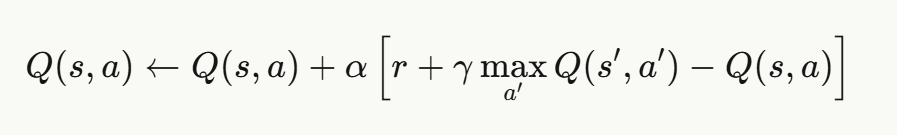

- alpha(학습률) : [0,1] 사이 값
  - 0.1 : 새로운 정보를 10%만 반영 (천천히 학습)
  - 1 : 새로운 정보를 100%만 반영 (빠르게 학습, 불안정)

- gamma(감마, 할인계수 discount factor)
  - 미래 보상 중요도
  - [0,1] 사이 값
  - gamma = 0 즉각적인 보상만 중요
  - gamma = 0.9 먼 미래도 중요

- r (reward  보상)
  - 행동 a를 취했을 얻을 수 있는 즉각적인 보상

- maxQ(s', a')
  - 다음 상태에서 가능한 최대 Q value




In [5]:
import numpy as np

# 1. 초기 설정 (Q-table 초기화)
# 16개의 상태(4x4)와 4개의 행동(상하좌우) 가정
q_table = np.zeros((16, 4))

# 예시 데이터 삽입
current_state = 0
action = 2  # RIGHT
next_state = 1
reward = 0

# 현재 Q-value 설정
q_table[current_state, action] = 0.5

# 다음 상태(next_state)의 Q-values 설정
q_table[next_state, :] = [0.3, 0.4, 0.6, 0.7]

# 2. 하이퍼파라미터
alpha = 0.1  # Learning Rate
gamma = 0.9  # Discount Factor

# 3. Q-Learning 업데이트 공식 적용
# Target = R + γ * max(Q(s', a'))
max_next_q = np.max(q_table[next_state])
target = reward + gamma * max_next_q

# TD Error = Target - Old_Q
td_error = target - q_table[current_state, action]

# Q 업데이트: Q(s,a) ← Q(s,a) + α * TD_Error
old_q = q_table[current_state, action]
q_table[current_state, action] += alpha * td_error

# 4. 결과 출력
print(f"Target (목표값): {target:.3f}")
print(f"TD Error (오차): {td_error:.3f}")
print(f"Q(0, RIGHT): {old_q} → {q_table[current_state, action]:.3f} (개선됨!)")

Target (목표값): 0.630
TD Error (오차): 0.130
Q(0, RIGHT): 0.5 → 0.513 (개선됨!)


In [23]:
"""
Q-Learning 알고리즘:

1. Q-table 초기화
   모든 Q(s, a) = 0 (또는 작은 랜덤 값)

2. 반복 (각 에피소드마다):
   a. 환경 초기화 (s ← 초기 상태)

   b. 에피소드 종료까지 반복:
      i.   ε-greedy로 행동 a 선택
      ii.  행동 실행 → (s', r) 관찰
      iii. Q-value 업데이트:
           Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]
      iv.  s ← s' (다음 상태로 이동)

   c. ε 감소 (탐색 줄이기)

3. 수렴할 때까지 반복

- off-policy : 탐색하면서 (epsilon) 최적의 정책 학습
"""

"\nQ-Learning 알고리즘:\n\n1. Q-table 초기화\n   모든 Q(s, a) = 0 (또는 작은 랜덤 값)\n\n2. 반복 (각 에피소드마다):\n   a. 환경 초기화 (s ← 초기 상태)\n\n   b. 에피소드 종료까지 반복:\n      i.   ε-greedy로 행동 a 선택\n      ii.  행동 실행 → (s', r) 관찰\n      iii. Q-value 업데이트:\n           Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]\n      iv.  s ← s' (다음 상태로 이동)\n\n   c. ε 감소 (탐색 줄이기)\n\n3. 수렴할 때까지 반복\n\n- off-policy : 탐색하면서 (epsilon) 최적의 정책 학습\n"

In [6]:
"""
Q-Learning (Table):
┌─────────┬─────┬─────┬─────┬─────┐
│ State   │  L  │  D  │  R  │  U  │
├─────────┼─────┼─────┼─────┼─────┤
│ State 0 │ 0.1 │ 0.5 │ 0.8 │ 0.2 │
│ State 1 │ 0.3 │ 0.4 │ 0.6 │ 0.7 │
│   ...   │ ... │ ... │ ... │ ... │
│State 15 │ 0.0 │ 0.0 │ 0.0 │ 0.0 │
└─────────┴─────┴─────┴─────┴─────┘

DQN (Neural Network):
     State
       │
       ▼
┌──────────────┐
│ Input Layer  │
│ (state dim)  │
└──────┬───────┘
       │
       ▼
┌──────────────┐
│Hidden Layer 1│
│  (128 units) │
└──────┬───────┘
       │
       ▼
┌──────────────┐
│Hidden Layer 2│
│  (128 units) │
└──────┬───────┘
       │
       ▼
┌──────────────┐
│Output Layer  │
│ (n_actions)  │
└──────┬───────┘
       │
       ▼
  [Q(s,a₀), Q(s,a₁), Q(s,a₂), Q(s,a₃)]
"""

'\nQ-Learning (Table):\n┌─────────┬─────┬─────┬─────┬─────┐\n│ State   │  L  │  D  │  R  │  U  │\n├─────────┼─────┼─────┼─────┼─────┤\n│ State 0 │ 0.1 │ 0.5 │ 0.8 │ 0.2 │\n│ State 1 │ 0.3 │ 0.4 │ 0.6 │ 0.7 │\n│   ...   │ ... │ ... │ ... │ ... │\n│State 15 │ 0.0 │ 0.0 │ 0.0 │ 0.0 │\n└─────────┴─────┴─────┴─────┴─────┘\n\nDQN (Neural Network):\n     State\n       │\n       ▼\n┌──────────────┐\n│ Input Layer  │\n│ (state dim)  │\n└──────┬───────┘\n       │\n       ▼\n┌──────────────┐\n│Hidden Layer 1│\n│  (128 units) │\n└──────┬───────┘\n       │\n       ▼\n┌──────────────┐\n│Hidden Layer 2│\n│  (128 units) │\n└──────┬───────┘\n       │\n       ▼\n┌──────────────┐\n│Output Layer  │\n│ (n_actions)  │\n└──────┬───────┘\n       │\n       ▼\n  [Q(s,a₀), Q(s,a₁), Q(s,a₂), Q(s,a₃)]\n'

In [25]:
"""
CartPole DQN 예시:

Input: [cart_pos, cart_vel, pole_angle, pole_vel]
       4차원 벡터

       ↓ (4 → 128)

Hidden 1: [h1, h2, h3, ..., h128]
          128개 뉴런
          ReLU 활성화

       ↓ (128 → 128)

Hidden 2: [h1, h2, h3, ..., h128]
          128개 뉴런
          ReLU 활성화

       ↓ (128 → 2)

Output: [Q(s, 왼쪽), Q(s, 오른쪽)]
        2개 Q-values
"""

'\nCartPole DQN 예시:\n\nInput: [cart_pos, cart_vel, pole_angle, pole_vel]\n       4차원 벡터\n\n       ↓ (4 → 128)\n\nHidden 1: [h1, h2, h3, ..., h128]\n          128개 뉴런\n          ReLU 활성화\n\n       ↓ (128 → 128)\n\nHidden 2: [h1, h2, h3, ..., h128]\n          128개 뉴런\n          ReLU 활성화\n\n       ↓ (128 → 2)\n\nOutput: [Q(s, 왼쪽), Q(s, 오른쪽)]\n        2개 Q-values\n'